# Time Series Analysis with Exogenous Variables
## ARX and ARMAX Models for Business and Health Informatics

## Recommended Kaggle datasets

### Business dataset
**Walmart Store Sales Forecasting**  
Example Kaggle dataset: `yasserh/walmart-dataset`  
Typical variables include: `Date`, `Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Holiday_Flag`.

### Health informatics dataset
**Seasonal Influenza Dataset**  
Example Kaggle dataset: `khaledsharf/seasonal-influenza-dataset`  
Typical variables include weekly influenza activity indicators such as positive cases, tested specimens and positivity rate.


# 1. Conceptual Introduction

## 1.1 Why use exogenous variables?

Traditional AR, MA, ARMA and ARIMA models forecast a variable mainly from its own past values.

However, in business and healthcare, the target variable is often affected by external drivers.

### Business example

Weekly sales may be affected by:

- holidays;
- fuel price;
- temperature;
- unemployment;
- CPI;
- promotions.

### Health informatics example

Influenza activity may be affected by:

- number of specimens tested;
- seasonal week;
- previous positivity rate;
- public health patterns;
- regional dynamics.

---

## 1.2 ARX Model

An **ARX** model is an autoregressive model with exogenous variables.

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \epsilon_t
$$

Where:

- $y_t$ is the target time series;
- $y_{t-1}, y_{t-2}$ are lagged values of the target;
- $x_{1,t}, x_{2,t}$ are external/exogenous variables;
- $\epsilon_t$ is the error term.

### Managerial interpretation

ARX answers:

> How much of the future value can be explained by past values plus external business or health drivers?

---

## 1.3 ARMAX Model

An **ARMAX** model extends ARX by adding a moving-average error component.

$$
y_t = c + \phi_1 y_{t-1} + \theta_1 \epsilon_{t-1} + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \epsilon_t
$$

Where:

- AR part captures dependence on past target values;
- MA part captures dependence on past forecast errors;
- X part captures external predictors.

### Analytical interpretation

ARMAX can be useful when:

- the time series depends on its own history;
- external variables influence the target;
- error patterns are autocorrelated.


In [2]:
# 2. Setup

#import os
#import warnings
#warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

#pd.set_option("display.max_columns", 100)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_forecast(y_true, y_pred, label="Model"):
    return pd.DataFrame({
        "Model": [label],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "RMSE": [rmse(y_true, y_pred)],
        "MAPE_%": [mape(y_true, y_pred)]
    })


def adf_test(series, name="series"):
    series = pd.Series(series).dropna()
    result = adfuller(series)
    print(f"ADF Test for {name}")
    print("-" * 40)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    if result[1] < 0.05:
        print("Conclusion: likely stationary at 5% level.")
    else:
        print("Conclusion: likely non-stationary at 5% level.")


# 4. Business Case: Walmart Weekly Sales Forecasting

## 4.1 Business problem

A retailer wants to forecast weekly sales using both:

- previous sales behaviour;
- external business drivers.

### Target variable

$$ Weekly\_Sales_t $$

### Possible exogenous variables

- holiday flag;
- temperature;
- fuel price;
- CPI;
- unemployment.

### Business question

> Can external factors improve the forecast of weekly sales compared with using past sales alone?


In [6]:
# 4.2 Load Walmart dataset
# https://www.kaggle.com/datasets/ankitrajmishra/walmart
    #"/mnt/data/Walmart.csv",
    #"/mnt/data/walmart.csv"
walmart_file = "Walmart.csv"
walmart = pd.read_csv(walmart_file)
print("Loaded:", walmart_file)

walmart.head()


Loaded: Walmart.csv


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
# descriptive analytics overview

walmart.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [8]:
# 4.3 Prepare Walmart time series

walmart.columns = [c.strip() for c in walmart.columns]
walmart = walmart.rename(columns={"Holiday_Flag": "IsHoliday"})
walmart["Date"] = pd.to_datetime(walmart["Date"])


agg_dict = {"Weekly_Sales": "sum"}
for col in ["Temperature", "Fuel_Price", "CPI", "Unemployment"]:
    if col in walmart.columns:
        agg_dict[col] = "mean"
if "IsHoliday" in walmart.columns:
    agg_dict["IsHoliday"] = "max"

business_ts = walmart.groupby("Date").agg(agg_dict).sort_index()


business_ts["weekofyear"] = business_ts.index.isocalendar().week.astype(int)
business_ts["week_sin"] = np.sin(2 * np.pi * business_ts["weekofyear"] / 52)
business_ts["week_cos"] = np.cos(2 * np.pi * business_ts["weekofyear"] / 52)

business_ts.head()


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/tools/datetimes.py:1047: UserWarning: Parsing '19-02-2010' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/tools/datetimes.py:1047: UserWarning: Parsing '26-02-2010' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/tools/datetimes.py:1047: UserWarning: Parsing '19-03-2010' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/tools/datetim

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,weekofyear,week_sin,week_cos
Date,,,,,,,,,
2010-01-10,42239875.87,69.868000,2.734333,168.354706,8.475289,0,1,0.120537,0.992709
2010-02-04,50423831.26,53.120889,2.827333,167.789036,8.497711,0,5,0.568065,0.822984
2010-02-07,48917484.50,77.133333,2.793511,167.982101,8.428578,0,5,0.568065,0.822984
2010-02-19,48276993.78,37.719778,2.672067,167.871686,8.619311,0,7,0.748511,0.663123
2010-02-26,43968571.13,39.243556,2.683933,167.909657,8.619311,0,8,0.822984,0.568065


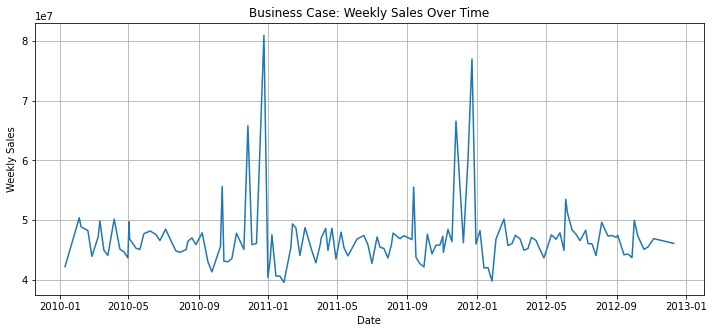

In [9]:
# 4.4 Visualise business time series

plt.figure(figsize=(12, 5))
plt.plot(business_ts.index, business_ts["Weekly_Sales"])
plt.title("Business Case: Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(True)
plt.show()


In [10]:
# 4.5 Stationarity test

adf_test(business_ts["Weekly_Sales"], "Weekly Sales")


ADF Test for Weekly Sales
----------------------------------------
ADF Statistic: -9.8377
p-value: 0.0000
Critical Values:
  1%: -3.4773
  5%: -2.8821
  10%: -2.5777
Conclusion: likely stationary at 5% level.


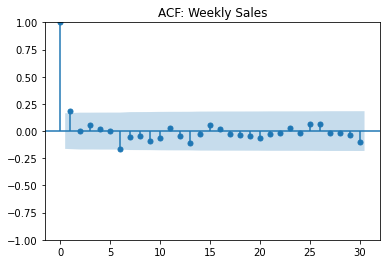

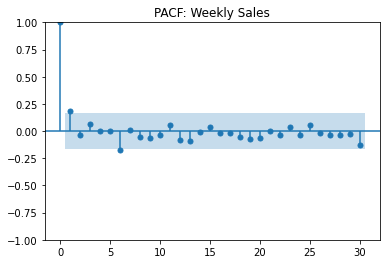

In [11]:
# 4.6 ACF and PACF plots

fig = plot_acf(business_ts["Weekly_Sales"].dropna(), lags=30)
plt.title("ACF: Weekly Sales")
plt.show()

fig = plot_pacf(business_ts["Weekly_Sales"].dropna(), lags=30, method="ywm")
plt.title("PACF: Weekly Sales")
plt.show()


## 4.7 Train/test split

For time series forecasting, we do **not** shuffle the data. We train on earlier observations and test on the most recent observations.


In [12]:
# 4.7 Train/test split

target_col = "Weekly_Sales"
exog_cols = [col for col in ["IsHoliday", "Temperature", "Fuel_Price", "CPI", "Unemployment", "week_sin", "week_cos"] if col in business_ts.columns]
print("Exogenous variables:", exog_cols)

data = business_ts[[target_col] + exog_cols].dropna()
test_size = 20
train = data.iloc[:-test_size]
test = data.iloc[-test_size:]

y_train = train[target_col]
y_test = test[target_col]
X_train = train[exog_cols]
X_test = test[exog_cols]

print(train.shape, test.shape)


Exogenous variables: ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'week_sin', 'week_cos']
(123, 8) (20, 8)


## 4.8 ARX Model for Business Forecasting

The ARX model uses lagged weekly sales and external variables such as holiday, temperature, fuel price, CPI and unemployment.


In [19]:
# 4.8 Fit ARX model

arx_model = AutoReg(endog=y_train, lags=10, exog=X_train, old_names=False)
arx_results = arx_model.fit()
print(arx_results.summary())


                            AutoReg Model Results                             
Dep. Variable:           Weekly_Sales   No. Observations:                  123
Model:                  AutoReg-X(10)   Log Likelihood               -1911.513
Method:               Conditional MLE   S.D. of innovations        5374101.363
Date:                Sat, 16 May 2026   AIC                           3861.025
Time:                        09:04:21   BIC                           3912.846
Sample:                            10   HQIC                          3882.053
                                  123                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.143e+08   2.86e+08     -1.097      0.273   -8.76e+08    2.47e+08
Weekly_Sales.L1      0.0683      0.099      0.687      0.492      -0.127       0.263
Weekly_Sales.L2     -0.1298 

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [20]:
# 4.9 Forecast with ARX model

arx_forecast = arx_results.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog_oos=X_test)
arx_forecast.index = y_test.index
arx_metrics = evaluate_forecast(y_test, arx_forecast, "Business ARX")
arx_metrics


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/deterministic.py:302: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


,Model,MAE,RMSE,MAPE_%
0,Business ARX,1.743142e+06,2.164524e+06,3.775945


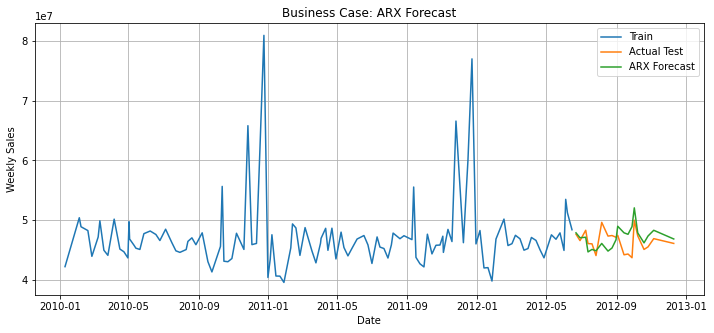

In [21]:
# 4.10 Plot ARX forecast

plt.figure(figsize=(12, 5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual Test")
plt.plot(arx_forecast.index, arx_forecast, label="ARX Forecast")
plt.title("Business Case: ARX Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()


## 4.11 ARMAX Model for Business Forecasting

The ARMAX model adds a moving-average component. In `statsmodels`, ARMAX can be fitted using `SARIMAX` with `order=(p,0,q)` and exogenous variables.


In [25]:
# 4.11 Fit ARMAX model

armax_model = SARIMAX(y_train, exog=X_train, order=(2, 1, 2), trend="c", enforce_stationarity=False, enforce_invertibility=False)
armax_results = armax_model.fit(disp=False)
print(armax_results.summary())


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  123
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -2029.201
Date:                Sat, 16 May 2026   AIC                           4084.402
Time:                        09:09:48   BIC                           4120.530
Sample:                             0   HQIC                          4099.072
                                - 123                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept    -2.887e+05   2.07e+05     -1.398      0.162   -6.93e+05    1.16e+05
IsHoliday    -5.384e+05   1.26e+04    -42.667      0.000   -5.63e+05   -5.14e+05
Temperature  -6.769e+04   5.81e+04     -1.16

In [26]:
# 4.12 Forecast with ARMAX model

armax_forecast_result = armax_results.get_forecast(steps=len(y_test), exog=X_test)
armax_forecast = armax_forecast_result.predicted_mean
armax_forecast.index = y_test.index
armax_metrics = evaluate_forecast(y_test, armax_forecast, "Business ARMAX")
pd.concat([arx_metrics, armax_metrics], ignore_index=True)


/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Model,MAE,RMSE,MAPE_%
0,Business ARX,1.743142e+06,2.164524e+06,3.775945
1,Business ARMAX,2.947933e+06,3.542694e+06,6.213347


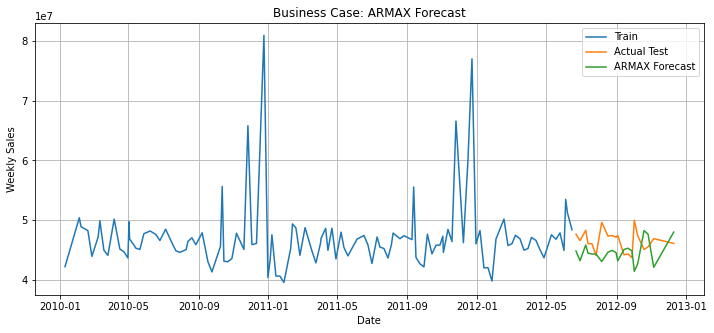

In [27]:
# 4.13 Plot ARMAX forecast

plt.figure(figsize=(12, 5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual Test")
plt.plot(armax_forecast.index, armax_forecast, label="ARMAX Forecast")
plt.title("Business Case: ARMAX Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()


## 4.14 Business Interpretation

Ask students:

1. Did the ARX or ARMAX model perform better?
2. Which exogenous variables were useful?
3. Does including external variables improve business forecasting?
4. How could this help a retailer?

Possible managerial applications:

- inventory planning;
- staffing decisions;
- promotional planning;
- holiday demand preparation;
- regional performance monitoring.


# 5. Health Informatics Case: Influenza Activity Forecasting

## 5.1 Health informatics problem

A public health analyst wants to forecast influenza activity using weekly surveillance data.

### Possible target variables

- number of positive cases;
- percentage positive;
- influenza-like illness indicator.

### Possible exogenous variables

- number of specimens tested;
- seasonal week indicators;
- lagged surveillance signals.

### Health question

> Can exogenous variables improve forecasting of influenza activity?


In [36]:
# 5.2 Load influenza dataset

flu_paths = "Seasonal influenza.csv"

flu = pd.read_csv(flu_paths)
print("Loaded:", flu_paths)

#flu.head()
flu.columns

# target variable: Number of Infected after the week ending date



Loaded: Seasonal influenza.csv


Index(['season', 'date_code', 'weekending', 'region', 'Respiratory_Virus',
       'Number_Positive', 'Specimens_Tested', 'Percent_Positive'],
      dtype='object')

In [37]:
flu

,season,date_code,weekending,region,Respiratory_Virus,Number_Positive,Specimens_Tested,Percent_Positive
0,2009-2010,200940,10/10/2009,Bay Area,Influenza_A,36,220,16.36
1,2009-2010,200940,10/10/2009,Bay Area,Influenza_B,0,220,0.00
2,2009-2010,200940,10/10/2009,Bay Area,Total_Influenza,36,220,16.36
3,2009-2010,200940,10/10/2009,Bay Area,RSV,0,190,0.00
4,2009-2010,200940,10/10/2009,California,Influenza_A,1077,3324,32.40
...,...,...,...,...,...,...,...,...
50006,2019-2020,202039,9/26/2020,Upper/Lower Southern,Parainfluenza_2,0,0,NaN
50007,2019-2020,202039,9/26/2020,Upper/Lower Southern,Parainfluenza_3,0,0,NaN
50008,2019-2020,202039,9/26/2020,Upper/Lower Southern,Parainfluenza_4,0,0,NaN
50009,2019-2020,202039,9/26/2020,Upper/Lower Southern,Parainfluenza_UnknownType,0,0,NaN


In [38]:
flu.describe()

,date_code,Number_Positive,Specimens_Tested,Percent_Positive
count,50011.000000,50011.000000,50011.000000,42414.000000
mean,201658.047570,20.653936,351.877027,3.943707
std,263.947403,91.746507,611.778964,7.121999
min,200940.000000,0.000000,0.000000,0.000000
25%,201507.000000,0.000000,40.000000,0.000000
50%,201707.000000,1.000000,133.000000,0.710000
75%,201849.000000,7.000000,402.000000,4.550000
max,202039.000000,3120.000000,8013.000000,100.000000


In [39]:
flu.columns

Index(['season', 'date_code', 'weekending', 'region', 'Respiratory_Virus',
       'Number_Positive', 'Specimens_Tested', 'Percent_Positive'],
      dtype='object')

In [41]:
# 5.3 Prepare influenza time series

flu.columns = [c.strip() for c in flu.columns] # clean column names

#flu
#health_ts.head()


In [ ]:
flu["weekending"] = pd.to_datetime(flu["Year", 

In [ ]:
# 5.4 Visualise health time series

plt.figure(figsize=(12, 5))
plt.plot(health_ts.index, health_ts[health_target])
plt.title(f"Health Informatics Case: {health_target} Over Time")
plt.xlabel("Date")
plt.ylabel(health_target)
plt.grid(True)
plt.show()


In [ ]:
# 5.5 Stationarity test

adf_test(health_ts[health_target], health_target)


In [ ]:
# 5.6 ACF and PACF plots

fig = plot_acf(health_ts[health_target].dropna(), lags=30)
plt.title(f"ACF: {health_target}")
plt.show()

fig = plot_pacf(health_ts[health_target].dropna(), lags=30, method="ywm")
plt.title(f"PACF: {health_target}")
plt.show()


In [ ]:
# 5.7 Train/test split for health case

health_data = health_ts[[health_target] + health_exog_cols].dropna()
test_size = 24
if len(health_data) <= test_size + 30:
    test_size = max(8, int(len(health_data) * 0.2))

health_train = health_data.iloc[:-test_size]
health_test = health_data.iloc[-test_size:]

yh_train = health_train[health_target]
yh_test = health_test[health_target]
Xh_train = health_train[health_exog_cols]
Xh_test = health_test[health_exog_cols]

print(health_train.shape, health_test.shape)


## 5.8 ARX Model for Health Informatics

This model forecasts influenza activity using past influenza activity, testing volume and seasonal weekly patterns.


In [ ]:
# 5.8 Fit health ARX model

health_arx_model = AutoReg(endog=yh_train, lags=2, exog=Xh_train, old_names=False)
health_arx_results = health_arx_model.fit()
print(health_arx_results.summary())


In [ ]:
# 5.9 Forecast with health ARX model

health_arx_forecast = health_arx_results.predict(start=len(yh_train), end=len(yh_train) + len(yh_test) - 1, exog_oos=Xh_test)
health_arx_forecast.index = yh_test.index
health_arx_metrics = evaluate_forecast(yh_test, health_arx_forecast, "Health ARX")
health_arx_metrics


In [ ]:
# 5.10 Plot health ARX forecast

plt.figure(figsize=(12, 5))
plt.plot(yh_train.index, yh_train, label="Train")
plt.plot(yh_test.index, yh_test, label="Actual Test")
plt.plot(health_arx_forecast.index, health_arx_forecast, label="ARX Forecast")
plt.title("Health Informatics Case: ARX Forecast")
plt.xlabel("Date")
plt.ylabel(health_target)
plt.legend()
plt.grid(True)
plt.show()


## 5.11 ARMAX Model for Health Informatics

This model adds a moving-average component to account for autocorrelated forecasting errors.


In [ ]:
# 5.11 Fit health ARMAX model

health_armax_model = SARIMAX(yh_train, exog=Xh_train, order=(2, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False)
health_armax_results = health_armax_model.fit(disp=False)
print(health_armax_results.summary())


In [ ]:
# 5.12 Forecast with health ARMAX model

health_armax_forecast_result = health_armax_results.get_forecast(steps=len(yh_test), exog=Xh_test)
health_armax_forecast = health_armax_forecast_result.predicted_mean
health_armax_forecast.index = yh_test.index
health_armax_metrics = evaluate_forecast(yh_test, health_armax_forecast, "Health ARMAX")
pd.concat([health_arx_metrics, health_armax_metrics], ignore_index=True)


In [ ]:
# 5.13 Plot health ARMAX forecast

plt.figure(figsize=(12, 5))
plt.plot(yh_train.index, yh_train, label="Train")
plt.plot(yh_test.index, yh_test, label="Actual Test")
plt.plot(health_armax_forecast.index, health_armax_forecast, label="ARMAX Forecast")
plt.title("Health Informatics Case: ARMAX Forecast")
plt.xlabel("Date")
plt.ylabel(health_target)
plt.legend()
plt.grid(True)
plt.show()


## 5.14 Health Informatics Interpretation

Ask students:

1. Did ARX or ARMAX perform better?
2. Which exogenous variables contributed to the forecast?
3. How could the forecast support public health planning?
4. What are the risks of using forecasting models in health contexts?

Possible applications:

- early warning dashboards;
- hospital staffing;
- vaccine campaign timing;
- laboratory testing planning;
- public health resource allocation.

Important warning:

> A forecast is a decision-support tool, not a replacement for professional judgement or epidemiological expertise.


# 6. ARX vs ARMAX Comparison

## ARX

Advantages:

- easier to explain;
- useful when external variables are important;
- interpretable for managers and analysts.

Limitations:

- may not capture autocorrelated errors well.

## ARMAX

Advantages:

- includes autoregression, exogenous variables and moving-average error structure;
- may perform better when forecast errors are serially correlated.

Limitations:

- more complex;
- parameter interpretation can be harder;
- requires more care in diagnostics.

---

# 7. Teaching Questions

## Business case

1. What is the target variable?
2. What are the exogenous variables?
3. Which external factors might influence sales?
4. Which model performs better?
5. How can managers use the forecast?

## Health case

1. What is the target health indicator?
2. What external health or surveillance variables are used?
3. How can forecasts support healthcare decisions?
4. What ethical risks exist in health forecasting?
5. What further data would improve the model?

---

# 8. Extension Activities

Students can extend this notebook by:

1. changing the AR and MA orders;
2. adding seasonal features;
3. trying SARIMAX seasonal orders;
4. comparing with Prophet, XGBoost or LSTM;
5. using cross-validation with rolling windows;
6. adding confidence intervals;
7. building a dashboard from the forecasts.
